In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
import matplotlib.patches as patches
import os
import cv2
import torch
from PIL import Image

2024-12-26 16:40:44.973013: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1735211444.984624  103610 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1735211444.987975  103610 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-26 16:40:45.000966: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
train_img_files = os.listdir('/home/divya/PycharmProjects/SmartSentinel/fall_dataset/images/train')
train_img_files.sort()
r1 = '/home/divya/PycharmProjects/SmartSentinel/fall_dataset/images/train/'
train_label_files = os.listdir('/home/divya/PycharmProjects/SmartSentinel/fall_dataset/labels/train')
train_label_files.sort()
r2 = '/home/divya/PycharmProjects/SmartSentinel/fall_dataset/labels/train/'

In [3]:
print(len(train_img_files))
print(len(train_label_files))

573
573


In [4]:
complete_images = []
complete_class = []

In [5]:
for i in range(len(train_img_files)):
    img = plt.imread(r1+train_img_files[i])
    with open(r2+train_label_files[i],'r') as file:
        r = file.readlines()
    bounding_boxes = []
    for j in r:
        j = j.split()
        bounding_boxes.append([int(j[0]),float(j[1]),float(j[2]),float(j[3]),float(j[4])])
    for box in bounding_boxes:
        image_height, image_width, _ = img.shape
        xmin, ymin, width, height = box[1:]
        xmin = int(xmin * image_width)
        ymin = int(ymin * image_height)
        width = int(width * image_width)
        height = int(height * image_height)
        complete_class.append(box[0])
        complete_images.append(img[ymin-height//2:ymin+height//2, xmin-width//2:xmin+width//2])

In [6]:
pref_size = (128,128)
for i in range(len(complete_images)):
    complete_images[i] = cv2.resize(complete_images[i],pref_size)

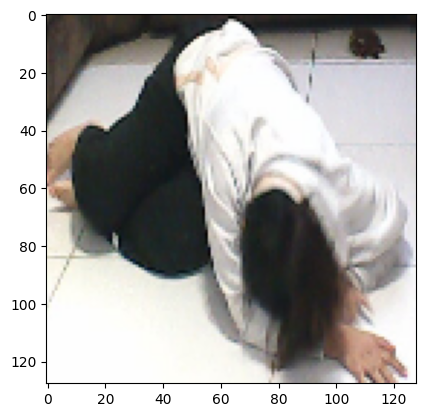

In [7]:
img = complete_images[86]
plt.imshow(img)
plt.show()

In [8]:
df = pd.DataFrame()
df['Images'] = complete_images
df['Class'] = complete_class
df['Images']/=255

In [9]:
# from tensorflow import keras

# model = keras.Sequential([
#     # First Convolutional Layer
#     keras.layers.Conv2D(16, (3, 3), padding='same', input_shape=(128, 128, 3), activation='relu'),
#     keras.layers.MaxPooling2D(),

#     # Second Convolutional Layer
#     keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
#     keras.layers.MaxPooling2D(),

#     # Third Convolutional Layer
#     keras.layers.Conv2D(64, (3, 3), activation='relu'),
#     keras.layers.MaxPooling2D(),
    
#     # Flatten layer to transition from convolutional to dense layers
#     keras.layers.Flatten(),

#     # Dense (Fully Connected) Layers
#     keras.layers.Dense(128, activation='relu'),

#     # Output layer (Assuming binary classification, use 'sigmoid' for binary, 'softmax' for multi-class)
#     keras.layers.Dense(3, activation='softmax')
# ])

# # Compile the model
# model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# # Display the model summary
# model.summary()


In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Load VGG16 model pre-trained on ImageNet data
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Create a new model by adding your classification layers
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(3, activation='softmax'))  # Binary classification, so use 1 output with sigmoid activation
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Summary of the model architecture
model.summary()

I0000 00:00:1735211449.021832  103610 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2279 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,867 (64.14 MB)

 Trainable params: 2,098,179 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
X_train = np.array(df['Images'].tolist())
y_train = np.array(df['Class'])
model.fit(X_train, y_train, epochs=20)

Epoch 1/20


I0000 00:00:1735211462.095701  103703 service.cc:148] XLA service 0x7fad2400c570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1735211462.096637  103703 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2024-12-26 16:41:02.145121: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1735211462.323691  103703 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/21 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4167 - loss: 2.1861

I0000 00:00:1735211467.541560  103703 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.5638 - loss: 1.4514
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7609 - loss: 0.5357
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8482 - loss: 0.3652
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8851 - loss: 0.2864
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9390 - loss: 0.2067
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9376 - loss: 0.1682
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9448 - loss: 0.1547
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9822 - loss: 0.0948
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9674 - loss: 0.0982
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9786 - loss: 0.0865
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9832 - loss: 0.0649
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9874 -

In [12]:
train_img_files = os.listdir('/home/divya/PycharmProjects/SmartSentinel/fall_dataset/images/val')
train_img_files.sort()
r1 = '/home/divya/PycharmProjects/SmartSentinel/fall_dataset/images/val/'
train_label_files = os.listdir('/home/divya/PycharmProjects/SmartSentinel/fall_dataset/labels/val')
train_label_files.sort()
r2 = '/home/divya/PycharmProjects/SmartSentinel/fall_dataset/labels/val/'

In [13]:
print(len(train_img_files))
print(len(train_label_files))

182
183


In [14]:
complete_images = []
complete_class = []

In [15]:
for i in range(len(train_img_files)):
    img = plt.imread(r1+train_img_files[i])
    with open(r2+train_label_files[i],'r') as file:
        r = file.readlines()
    bounding_boxes = []
    for j in r:
        j = j.split()
        bounding_boxes.append([int(j[0]),float(j[1]),float(j[2]),float(j[3]),float(j[4])])
    for box in bounding_boxes:
        image_height, image_width, _ = img.shape
        xmin, ymin, width, height = box[1:]
        xmin = int(xmin * image_width)
        ymin = int(ymin * image_height)
        width = int(width * image_width)
        height = int(height * image_height)
        complete_class.append(box[0])
        complete_images.append(img[ymin-height//2:ymin+height//2, xmin-width//2:xmin+width//2])

In [16]:
pref_size = (128,128)
for i in range(len(complete_images)):
    complete_images[i] = cv2.resize(complete_images[i],pref_size)

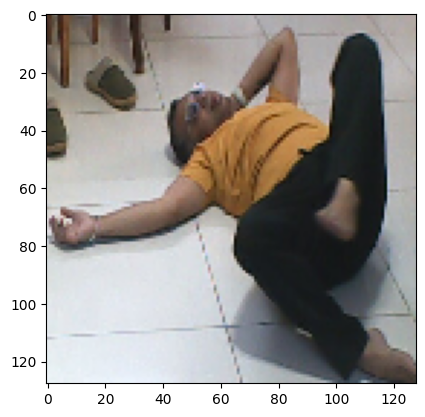

In [17]:
img = complete_images[86]
plt.imshow(img)
plt.show()

In [18]:
df = pd.DataFrame()
df['Images'] = complete_images
df['Class'] = complete_class
df['Images']/=255

In [19]:
X_test = np.array(df['Images'].tolist())
y_test = np.array(df['Class'])

In [20]:
model.evaluate(X_test,y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 754ms/step - accuracy: 0.8498 - loss: 0.5826


[0.9696691632270813, 0.7891891598701477]

In [21]:
# Load YOLOv5 model

yolo_model = torch.hub.load('ultralytics/yolov5', 'yolov5s')
yolo_model.classes = [0]

Using cache found in /home/divya/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-12-26 Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3902MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [23]:

def print_and_save_bounding_boxes(results, image_path):
    # Extract image width and height
    img = Image.open(image_path)
    image_width, image_height = img.size
    img_filename = os.path.splitext(os.path.basename(image_path))[0]  # Get filename without path or extension

    # Create filename for text file
    filename = f"{img_filename}.txt"
    with open(filename, "w") as f:
        boxes =[]
        for i, detection in enumerate(results.pandas().xyxy[0].values):  # Use .values to access data
            x_min, y_min, x_max, y_max, confidence, class_id, *extra_values = detection.tolist()
            if(confidence>0.5):
                label = results.names[int(class_id)]
                class_label = class_id
                x_center = (x_min + x_max) / 2 / image_width
                y_center = (y_min + y_max) / 2 / image_height
                norm_width = (x_max - x_min) / image_width
                norm_height = (y_max - y_min) / image_height

                print(f"Labels: {x_center} {y_center} {norm_width} {norm_height} {confidence}")
                print(f"Object {i + 1}: {label} (Confidence: {confidence:.2f})")
                f.write(f"{label} {x_center} {y_center} {norm_width} {norm_height} {confidence}\n")
                temp = [x_center,y_center,norm_width,norm_height]
                boxes.append(temp)
        return boxes         

# Function to draw bounding box on the detected object and print coordinates
def draw_bounding_box(img_array, object_number, x, y, x_plus_w, y_plus_h):
    color = (0, 255, 0)  # BGR
    cv2.rectangle(img_array, (x, y), (x_plus_w, y_plus_h), color, 2)
    

# Function to perform object detection
def detect_objects(image_path):
    # Load image
    img = Image.open(image_path)

    # Convert Image object to NumPy array
    img_array = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)  # Note: Color conversion
    results = yolo_model(img, size=640)  # includes NMS
    #results.print()  
    results.show()
    boxes  = print_and_save_bounding_boxes(results, image_path)
    # print("hi:",results.xyxy[0])
    num_bounding_boxes = len(results.xyxy[0])  # Number of bounding boxes
    print(f"Number of Objects Detected {num_bounding_boxes}")
    # Draw bounding boxes
    for i in range(num_bounding_boxes):
        x, y, x_plus_w, y_plus_h, _, _ = results.xyxy[0][i]
        draw_bounding_box(img_array, i + 1, round(x.item()), round(y.item()), round(x_plus_w.item()), round(y_plus_h.item()))

    return boxes


/home/divya/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


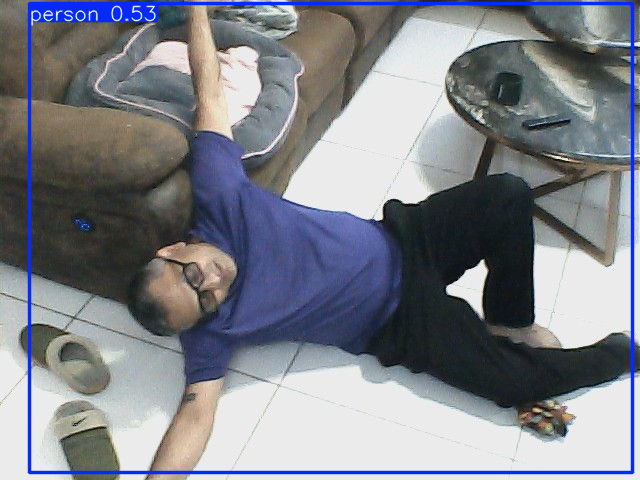

Labels: 0.5173015117645263 0.4961856842041016 0.9409092903137207 0.9768302917480469 0.5302982926368713
Object 1: person (Confidence: 0.53)
Number of Objects Detected 1
[[0.5173015117645263, 0.4961856842041016, 0.9409092903137207, 0.9768302917480469]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
0
Fall detected


In [25]:
image_path = '/home/divya/PycharmProjects/SmartSentinel/fall_dataset/images/train/fall0003.jpg'  # replace 'your_image.jpg' with the actual image file path
def predictions (image_path):
#     img = cv2.imread(image_path)
#     img = cv2.resize(img, pref_size)
#     img = img / 255.0
#     img = np.expand_dims(img, axis=0)
    
#     for i in range(len(train_img_files)):
    img = plt.imread(image_path)
#     with open(r2+train_label_files[i],'r') as file:
#         r = file.readlines()
    bounding_boxes = detect_objects(image_path)
    print(bounding_boxes)
#     for j in r:
#         j = j.split()
#        bounding_boxes.append([int(j[0]),float(j[1]),float(j[2]),float(j[3]),float(j[4])])
    complete_images=[]
    for box in bounding_boxes:
        image_height, image_width, _ = img.shape
        xmin, ymin, width, height = box[:]
        xmin = int(xmin * image_width)
        ymin = int(ymin * image_height)
        width = int(width * image_width)
        height = int(height * image_height)
#         complete_class.append(box[0])
        complete_images.append(img[ymin-height//2:ymin+height//2, xmin-width//2:xmin+width//2])
    for cropped_img in complete_images:
        plt.imshow(cropped_img)
        plt.axis('off')  # Turn off axis
        plt.show()
#         img_n = cv2.resize(img, pref_size)
#         plt.imshow(img_n)
#         plt.show()
#         print(img_n.shape)
#         img_n = img_n /255.0
#         img_n = np.expand_dims(img, axis=0)
#         predictions = model.predict(img_n)
#         print(np.argmax(predictions))
        cropped_img_resized = cv2.resize(cropped_img, pref_size)
        plt.imshow(cropped_img_resized)
        plt.show()
        cropped_img_resized = cropped_img_resized / 255.0
        #cv2.imshow(cropped_img_resized)
        cropped_img_resized = np.expand_dims(cropped_img_resized, axis=0)
        predictions = model.predict(cropped_img_resized)
        k=np.argmax(predictions)
        print(np.argmax(predictions))
        if(k==0):
            print("Fall detected")
        elif(k==1):
            print("No fall detected. Person is walking or standing")
        else:
            print("No fall detected. Person is sitting.")
predictions (image_path)
    

In [26]:
path = '/kaggle/input/abhi-fall/WhatsApp Image 2024-02-04 at 19.30.32_1795db8c.png.jpg'
predictions(path)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/abhi-fall/WhatsApp Image 2024-02-04 at 19.30.32_1795db8c.png.jpg'

In [28]:
model.save("model_fall.keras")